In [1]:
# Q1: Supervised Learning — Heart Disease Prediction

# This notebook builds and evaluates classification models to predict whether a patient has heart disease.
     


In [2]:
# 1. Data Loading and Inspection

In [2]:
!mamba install pandas
import pandas as pd

df = pd.read_csv('q1_heart_disease.csv')
print(f'Rows    : {df.shape[0]}')
print(f'Columns : {df.shape[1]}')
print(f'Shape   : {df.shape}')

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 5.20140000000596 seconds
All requested packages already installed.
Rows    : 800
Columns : 12
Shape   : (800, 12)


In [4]:
print('Column Data Types:')
print('-' * 40)
print(df.dtypes.to_string())

missing = df.isnull().sum()
print('\n Missing values per column:')
print('-' * 40)
print(missing.to_string())
print('-' * 40)
print(f'Total missing cells : {missing.sum()}')
print(f'Columns with missing : {(missing > 0).sum()}')

df.head()

Column Data Types:
----------------------------------------
age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64

 Missing values per column:
----------------------------------------
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
----------------------------------------
Total missing cells : 56
Columns with missing : 2


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


In [5]:
# 2. Exploratory Data Analysis

mambajs 0.19.13

Process pip requirements ...

Requirement seaborn already satisfied.


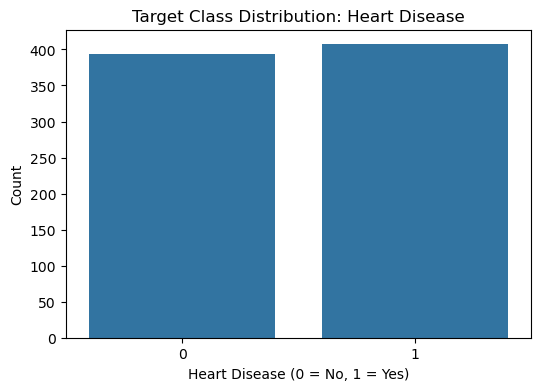

In [9]:
!pip install seaborn
import matplotlib.pyplot as plt
import seaborn as sns



# -------------------------------
plt.figure(figsize=(6,4))
sns.countplot(x="heart_disease", data=df)
plt.title("Target Class Distribution: Heart Disease")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

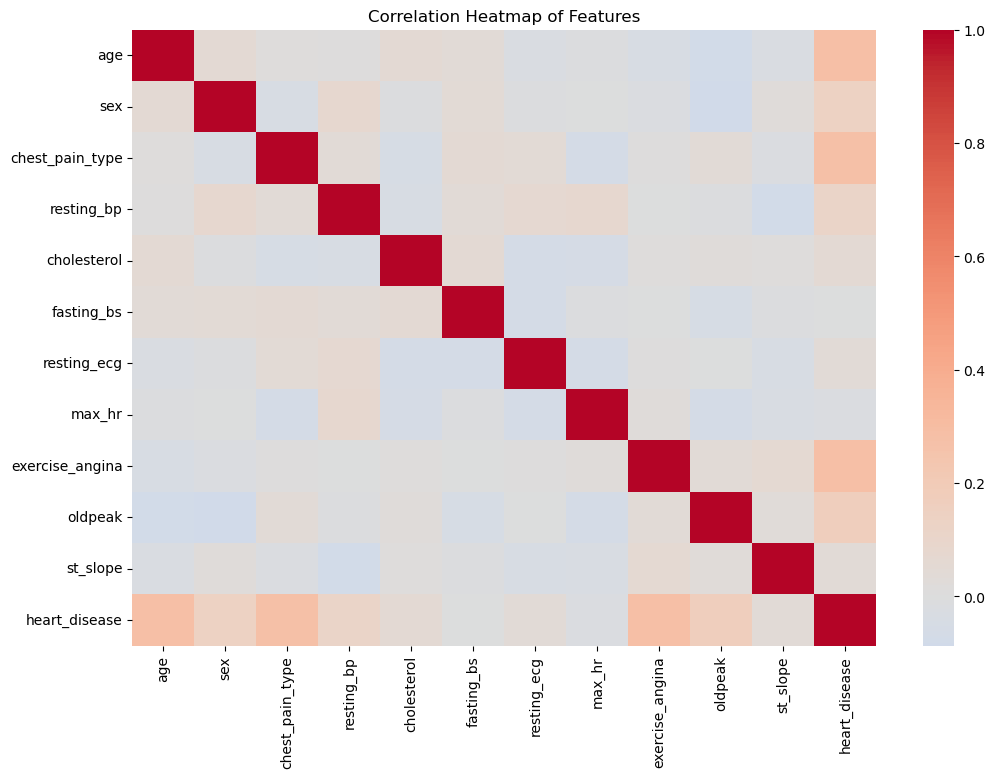

In [15]:
for col in df_numeric.select_dtypes(include=["object", "string"]).columns:
    df_numeric[col] = pd.factorize(df_numeric[col])[0]


plt.figure(figsize=(12,8))
corr = df_numeric.corr()
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Features")
plt.show()

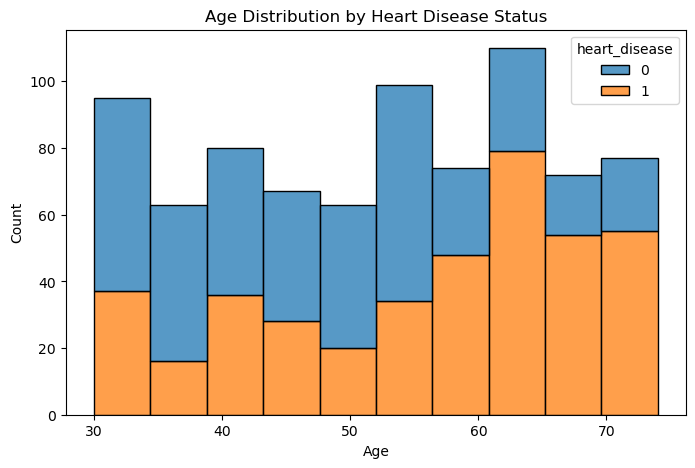

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="age", hue="heart_disease", multiple="stack", bins=10)
plt.title("Age Distribution by Heart Disease Status")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


In [23]:
# 3. Data Preprocessing

In [27]:
!mamba install scikit-learn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop("heart_disease", axis=1)
y = df_encoded["heart_disease"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, scikit-learn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 1.6882000000029802 seconds
All requested packages already installed.
Training set size: (640, 15)
Test set size: (160, 15)


In [28]:
# 4. Model Training

In [42]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer


df_encoded = pd.get_dummies(df, drop_first=True)


# Separate features and target
X = df_encoded.drop("heart_disease", axis=1)
y = df_encoded["heart_disease"]

# Impute missing values (numeric: median, categorical already one-hot encoded so 0/1)
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)



In [40]:


# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
print("Decision Tree Accuracy:", accuracy_score(y_test, dt.predict(X_test)))

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
print("Random Forest Accuracy:", accuracy_score(y_test, rf.predict(X_test)))

# Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb.predict(X_test)))

print("Models trained successfully")

Decision Tree Accuracy: 0.7
Random Forest Accuracy: 0.79375
Gradient Boosting Accuracy: 0.76875
Models trained successfully


In [44]:
# 5. Model Evaluation

Decision Tree Confusion Matrix:
 [[56 23]
 [25 56]]
Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.71      0.70        79
           1       0.71      0.69      0.70        81

    accuracy                           0.70       160
   macro avg       0.70      0.70      0.70       160
weighted avg       0.70      0.70      0.70       160



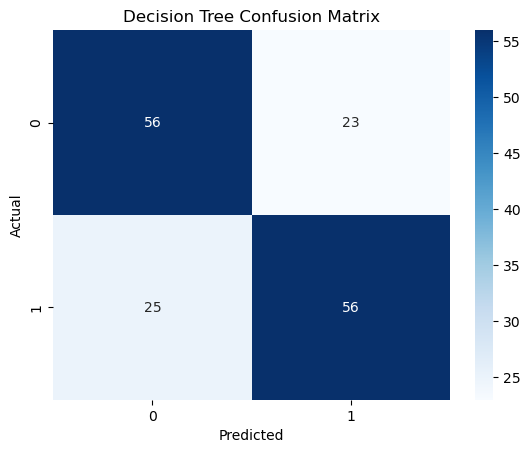

Random Forest Confusion Matrix:
 [[61 18]
 [15 66]]
Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160



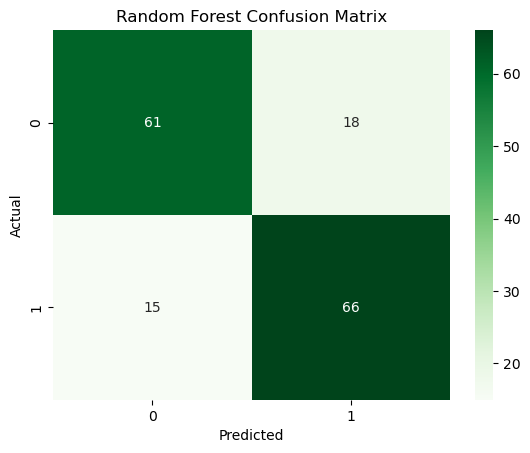

Gradient Boosting Confusion Matrix:
 [[61 18]
 [19 62]]
Gradient Boosting Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.77      0.77        79
           1       0.78      0.77      0.77        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



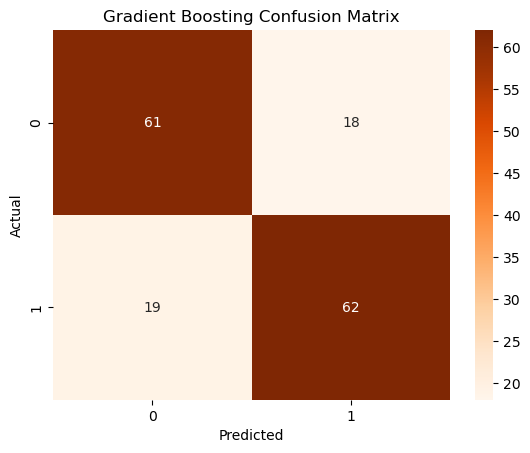

In [45]:
# Task 5: Model Evaluation

import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluate Decision Tree
y_pred_dt = dt.predict(X_test)
print("Decision Tree Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Decision Tree Classification Report:\n", classification_report(y_test, y_pred_dt))

# Plot confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt="d", cmap="Blues")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Evaluate Random Forest
y_pred_rf = rf.predict(X_test)
print("Random Forest Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Random Forest Classification Report:\n", classification_report(y_test, y_pred_rf))

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Evaluate Gradient Boosting
y_pred_gb = gb.predict(X_test)
print("Gradient Boosting Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))
print("Gradient Boosting Classification Report:\n", classification_report(y_test, y_pred_gb))

sns.heatmap(confusion_matrix(y_test, y_pred_gb), annot=True, fmt="d", cmap="Oranges")
plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [46]:
# Among the three models Random Forest performs best based on F1-score, precision
# and recall.
# It balances false positives and false negatives effectively making it more
#  reliable than accuracy alone.

In [60]:
# Task 6: Hyperparameter Tuning

In [63]:

from sklearn.model_selection import  GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
     
 


Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [62]:
best_model = grid.best_estimator_
y_pred_tuned = best_model.predict(X_test)

print("Tuned Model Performance: \n")
print(confusion_matrix(y_test, y_pred_tuned))
print(classification_report(y_test, y_pred_tuned))
     

Tuned Model Performance: 

[[59 20]
 [17 64]]
              precision    recall  f1-score   support

           0       0.78      0.75      0.76        79
           1       0.76      0.79      0.78        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



In [ ]:
# Hyperparameter tuning improves model performance by optimizing key parameters.
# The tuned model maintains strong performance and
# validates the choice of Random Forest.